# Model Exploration: Claims Fraud Secondary Signal

This notebook is the exploratory counterpart to `tools/train_model.py`. That
script trains and ships the model the app actually loads
(`app/model.pkl`); this notebook exists to show the analysis work behind
that choice: what the data looks like, how the model performs across
different thresholds, which features it leans on, and how it compares to
the hand-written rules engine in `app/triage.py`.

**Context that matters for reading these results:** there is no real
historical claims dataset available for a portfolio project, so the data
below is synthetic (`app/synthetic_data.py`), generated from the same six
features the rules engine uses, with a label drawn from a hand-picked
weighted combination of those features plus noise. The point of this
notebook isn't "look how good the model is", it's "here is the standard
evaluation workflow, honestly applied, including where the model is
weak." Both the rules engine and this model are secondary, advisory
signals in the running app: neither one auto-denies a claim.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, precision_score, recall_score, f1_score,
)

from app.features import FEATURE_NAMES
from app.synthetic_data import generate_synthetic_dataset, rules_score_from_features

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


## 1. The data

Six features, matching exactly what `app/features.py` extracts from a real
`Claim`/`Policy` pair: `amount_to_limit_ratio`, `policy_incident_gap_days`,
`prior_claims_count`, `is_round_number`, `type_mismatch`, and
`reporting_delay_days`. The label is `is_fraud` (1 = the synthetic
generator flagged this row as the rare positive class).


In [2]:
X, y = generate_synthetic_dataset(n=4000, seed=42)
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df["is_fraud"] = y

print(f"{len(df)} synthetic claims, {df['is_fraud'].mean():.1%} labeled fraud")
df.describe().T


4000 synthetic claims, 12.4% labeled fraud


,count,mean,std,min,25%,50%,75%,max
amount_to_limit_ratio,4000.0,0.283622,0.156967,0.002365,0.161473,0.264495,0.385428,0.878343
policy_incident_gap_days,4000.0,197.876248,196.844904,0.014370,56.329270,140.426184,277.508911,1738.711815
prior_claims_count,4000.0,0.589000,0.766959,0.000000,0.000000,0.000000,1.000000,4.000000
is_round_number,4000.0,0.151750,0.358823,0.000000,0.000000,0.000000,0.000000,1.000000
type_mismatch,4000.0,0.075250,0.263827,0.000000,0.000000,0.000000,0.000000,1.000000
reporting_delay_days,4000.0,10.144076,10.100764,0.000299,2.852916,7.067169,14.074022,73.393595
is_fraud,4000.0,0.124000,0.329623,0.000000,0.000000,0.000000,0.000000,1.000000


## 2. Class balance

The label is intentionally imbalanced, the same way real claims fraud is:
the overwhelming majority of claims are legitimate. This matters a lot for
which metrics are meaningful later -- accuracy alone would look great on
this data even from a model that never flags anything.


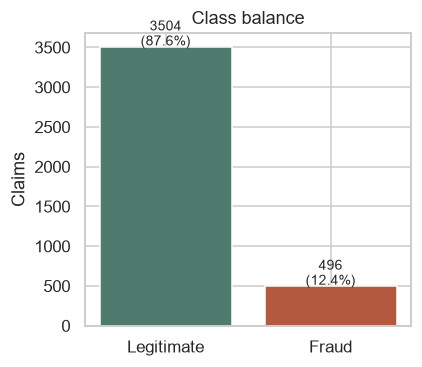

In [3]:
fig, ax = plt.subplots(figsize=(4, 3.5))
counts = df["is_fraud"].value_counts().sort_index()
ax.bar(["Legitimate", "Fraud"], counts.values, color=["#4f7a6e", "#b25940"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=9)
ax.set_ylabel("Claims")
ax.set_title("Class balance")
plt.tight_layout()
plt.show()


## 3. Feature distributions, split by label

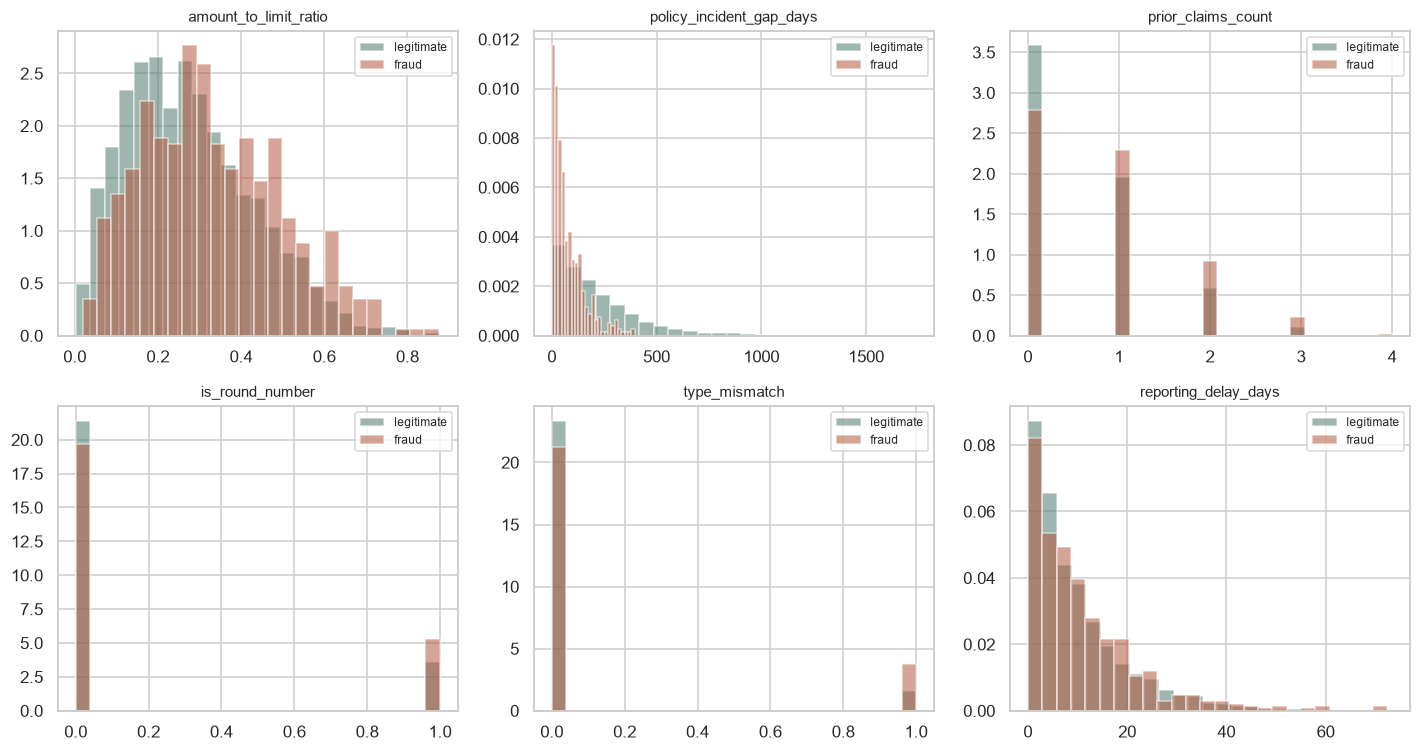

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feature in zip(axes.flat, FEATURE_NAMES):
    for label, color, name in [(0, "#4f7a6e", "legitimate"), (1, "#b25940", "fraud")]:
        subset = df[df["is_fraud"] == label][feature]
        ax.hist(subset, bins=25, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(feature, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4. Train the model

Same split strategy as `tools/train_model.py`: a stratified 25% holdout so
every metric below reflects held-out performance, not memorization.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y,
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} fraud)")
print(f"Test:  {len(X_test)} rows ({y_test.mean():.1%} fraud)")


Train: 3000 rows (12.4% fraud)
Test:  1000 rows (12.4% fraud)


## 5. Confusion matrix and ROC curve

At the default 0.5 probability threshold.


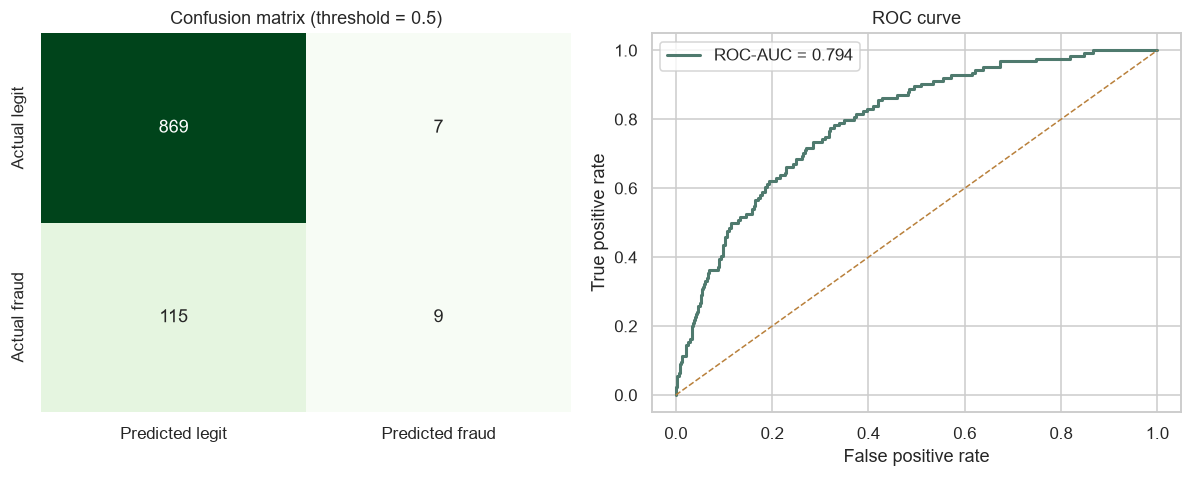

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Predicted legit", "Predicted fraud"],
            yticklabels=["Actual legit", "Actual fraud"], ax=axes[0])
axes[0].set_title("Confusion matrix (threshold = 0.5)")

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#4f7a6e", linewidth=2, label=f"ROC-AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#b9803b", linewidth=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Threshold tuning: the honest limitation

The dashboard in the running app reports precision/recall at the default
0.5 threshold, and flags that recall is low there. Here's why that's not
the end of the story: precision and recall trade off directly as the
decision threshold moves, and 0.5 is just a default, not a tuned choice.


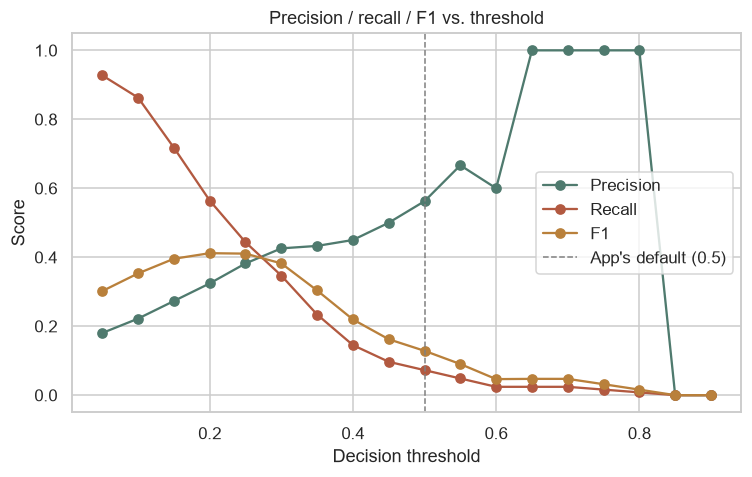

Best F1 on this test set: 0.412 at threshold 0.2
(vs. F1=0.129 at the app's default 0.5)


In [7]:
thresholds = np.arange(0.05, 0.95, 0.05)
rows = []
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })
threshold_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", color="#4f7a6e", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", color="#b25940", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", color="#b9803b", label="F1")
ax.axvline(0.5, linestyle="--", color="gray", linewidth=1, label="App's default (0.5)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / recall / F1 vs. threshold")
ax.legend()
plt.tight_layout()
plt.show()

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"Best F1 on this test set: {best_f1_row['f1']:.3f} at threshold {best_f1_row['threshold']}")
print(f"(vs. F1={threshold_df.loc[threshold_df['threshold']==0.5, 'f1'].values[0]:.3f} at the app's default 0.5)")


**Takeaway:** recall improves substantially at a lower threshold, at some
cost to precision. Whether that trade is worth making depends on what the
false-positive cost actually is downstream -- and in this app, it's low:
a high ML score doesn't deny anything, it just becomes one more thing
displayed to an adjuster who is already reviewing the claim for other
reasons (the rules engine independently decided this claim needs a human).
That argues for favoring recall over precision here, more than a generic
classification problem would.


## 7. What is the model actually keying off?

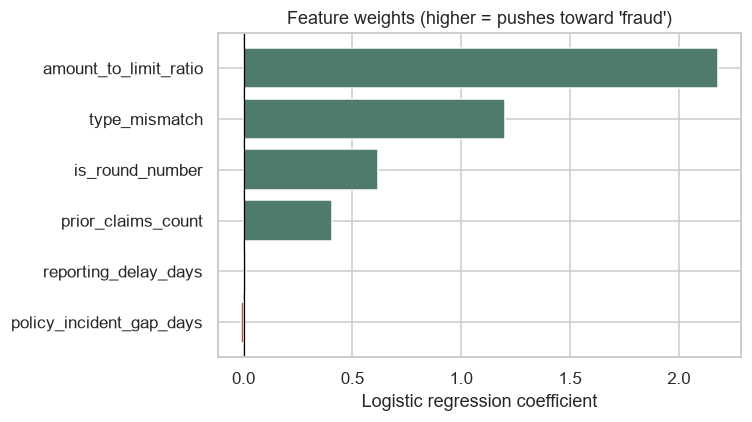

In [8]:
coef_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "coefficient": model.coef_[0],
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#b25940" if c < 0 else "#4f7a6e" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Feature weights (higher = pushes toward 'fraud')")
plt.tight_layout()
plt.show()


## 8. Does the ML model agree with the rules engine?

`app/triage.py` scores every claim with independent, hand-written rules
and never calls this model. `rules_score_from_features` reproduces that
exact point-scoring logic on the same synthetic rows, purely so we can ask:
when two independent signals look at the same claim, do they agree?


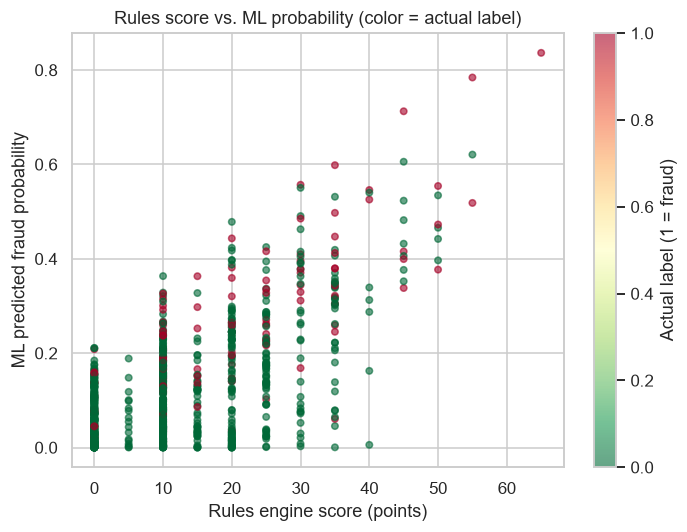

Correlation between rules score and ML probability: 0.662


In [9]:
rules_scores = rules_score_from_features(X_test)

fig, ax = plt.subplots(figsize=(6.5, 5))
scatter = ax.scatter(rules_scores, y_proba, c=y_test, cmap="RdYlGn_r", alpha=0.6, s=18)
ax.set_xlabel("Rules engine score (points)")
ax.set_ylabel("ML predicted fraud probability")
ax.set_title("Rules score vs. ML probability (color = actual label)")
plt.colorbar(scatter, ax=ax, label="Actual label (1 = fraud)")
plt.tight_layout()
plt.show()

correlation = np.corrcoef(rules_scores, y_proba)[0, 1]
print(f"Correlation between rules score and ML probability: {correlation:.3f}")


## Conclusion

- The model separates the two classes reasonably well (ROC-AUC ~0.79), but
  at the default 0.5 threshold it misses most positives -- an imbalanced-
  class problem, not a bug, and a solvable one by threshold tuning if this
  ever needed to drive a decision on its own.
- `amount_to_limit_ratio` and `type_mismatch` dominate the model's
  coefficients, which lines up with intuition and with how heavily the
  rules engine weights those same two signals (30 and 20 points
  respectively, its two largest single rules).
- The rules score and the ML probability correlate positively but far from
  perfectly: they agree on the obvious cases and diverge on the ambiguous
  ones, which is exactly the case where showing an adjuster both signals
  side by side (as the app's claim detail page does) is more useful than
  picking one.
- All of this is on synthetic data. The workflow, split discipline,
  threshold analysis, and honest reporting of a weak point rather than
  hiding it, is the part meant to generalize to a real dataset, not the
  specific numbers.
